# 6 · Temporal products & statistical series

These are **non-map** plots (plain matplotlib axes, not a `Map`):

- `temporal.TimeSeries` — reduce each member of a `DatasetCollection` to one value per time step.
- `temporal.Climatology` — group that series by a periodic label (season/month) into group means plus a min/max spread plume.
- `series.quantile_band` / `multiboxplot` / `stripes` — ensemble band, grouped box plots, and warming-stripes, wrapping cleopatra's `LineGlyph` / `HistogramGlyph`.

We build a synthetic 12-month stack by scaling the DEM with a seasonal cycle, then summarise it.

**Setup.** Inline plots + resolve the DEM path.

In [1]:
%matplotlib inline
from pathlib import Path

# Resolve the repo root so the bundled sample DEM is found whether this runs from
# docs/examples/ (mkdocs) or the repository root.
ROOT = Path.cwd()
while not (ROOT / "examples" / "data" / "LisbonElevation.tif").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DEM = str(ROOT / "examples" / "data" / "LisbonElevation.tif")
print("DEM:", DEM)

DEM: C:\gdrive\algorithms\serapeum-github-org\repos\visualization\Digital-Earth\examples\data\LisbonElevation.tif


Build a synthetic **12-month stack**: scale the DEM by a seasonal cosine (high in winter, low in summer) plus noise, and wrap the members in a `DatasetCollection` — a stand-in for a real time series of rasters.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pyramids.dataset import Dataset, GeoReference
from pyramids.dataset.collection import DatasetCollection
from digitalearth import series
from digitalearth.temporal import TimeSeries, Climatology

# Build a 12-month synthetic 'snow line' stack by scaling the DEM with a seasonal cycle.
ds = Dataset.read_file(DEM)
z = np.nan_to_num(ds.read_array(band=0).astype('float32'))
rng = np.random.default_rng(0)
members = []
for month in range(12):
    factor = 0.5 + 0.5 * np.cos((month - 1) / 12 * 2 * np.pi)  # winter high, summer low
    arr = (z * factor + rng.normal(0, 5, z.shape)).astype('float32')
    members.append(Dataset.from_array(arr=arr, geo_ref=GeoReference(geo=ds.geotransform, epsg=ds.epsg)))
dc = DatasetCollection(members[0], len(members), datasets=members)
print('members:', len(dc.datasets))

members: 12


## TimeSeries — monthly spatial-mean elevation proxy

**TimeSeries** — reduce each monthly raster to its spatial mean and plot the resulting curve (`temporal.TimeSeries` over the collection).

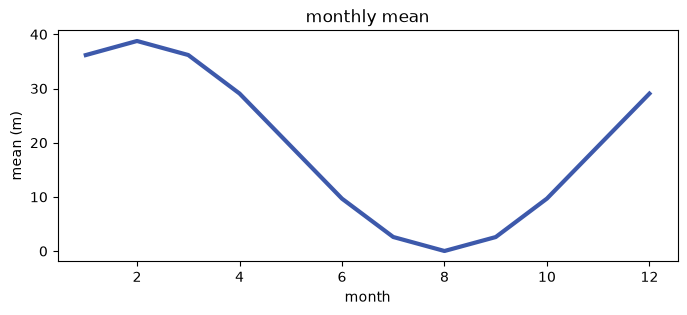

In [3]:
fig, ax = plt.subplots(figsize=(8, 3))
TimeSeries(dc).plot(times=list(range(1, 13)), ax=ax)
ax.set(xlabel='month', ylabel='mean (m)', title='monthly mean')
fig;

## Climatology — seasonal group means + spread plume

**Climatology** — group the same series by season and plot the per-group mean with a min/max spread plume (`temporal.Climatology`).

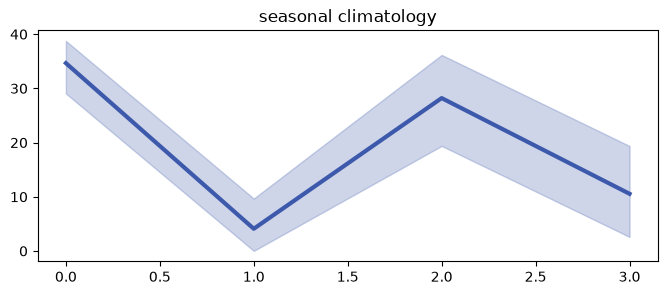

In [4]:
seasons = ['DJF','DJF','MAM','MAM','MAM','JJA','JJA','JJA','SON','SON','SON','DJF']
fig, ax = plt.subplots(figsize=(8, 3))
Climatology(dc, seasons).plot(ax=ax)
ax.set(title='seasonal climatology')
fig;

## Ensemble band (quantiles) and box plots

Make a synthetic **ensemble** (40 members × 24 steps) for the statistical helpers.

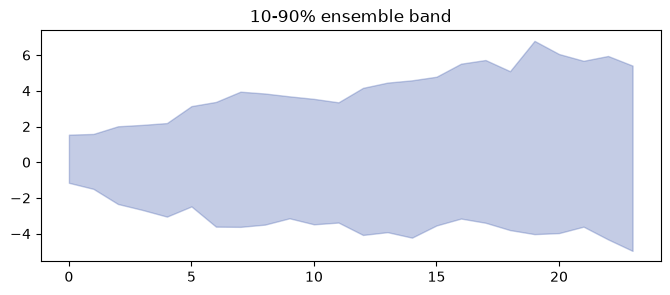

In [5]:
ensemble = rng.normal(size=(40, 24)).cumsum(axis=1)
fig, ax = plt.subplots(figsize=(8, 3))
series.quantile_band(ensemble, lower=0.1, upper=0.9, ax=ax, alpha=0.3)
ax.set_title('10-90% ensemble band')
fig;

**quantile_band** — shade the 10–90 % inter-quantile band across the ensemble, then **multiboxplot** draws one box per group (`series` helpers over cleopatra `LineGlyph` / `HistogramGlyph`).

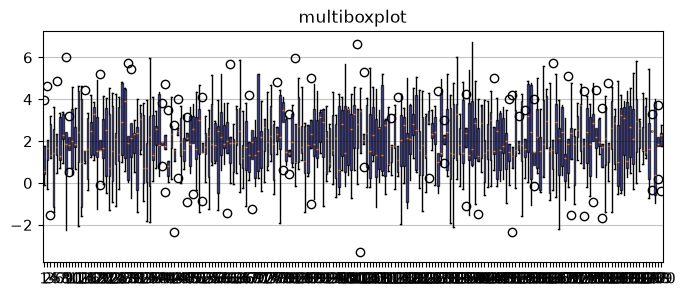

In [6]:
fig, ax = plt.subplots(figsize=(8, 3))
series.multiboxplot([rng.normal(m, 1, 200) for m in range(5)], ax=ax)
ax.set_title('multiboxplot')
fig;

## Warming stripes

**stripes** — a warming-stripes bar strip of a 1-D series (`series.stripes`).

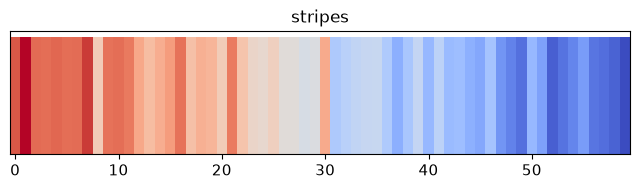

In [7]:
fig, ax = plt.subplots(figsize=(8, 1.6))
series.stripes(np.linspace(-1, 1, 60) + rng.normal(0, 0.2, 60), ax=ax)
ax.set_title('stripes')
fig;